In [1]:
import sys
!{sys.executable} -m pip install matplotlib

In [2]:
%pip install osmnx networkx
%pip install plotly -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import osmnx as ox      # Responsável por se conectar ao OpenStreetMap, baixar os dados reais da malha viária e extrair as coordenadas geográficas (latitude/longitude).
import networkx as nx   # Responsável por toda a "matemática" do projeto: cria a estrutura de dados do grafo e calcula as métricas exigidas (grau, hubs, betweenness e k-core).
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
# CÉLULA 2: DOWNLOAD DA MALHA VIÁRIA E PREPARAÇÃO
place = "Capim Macio, Natal, Rio Grande do Norte, Brazil"

# Baixando o grafo focado apenas em vias para veículos
print("Baixando o grafo. Isso pode levar alguns segundos...")
G = ox.graph_from_place(place, network_type="drive")

# Convertendo para grafo não-direcionado simples (Garante compatibilidade com o k-core)
# Usando a conversão nativa do NetworkX para evitar erros de versão do OSMnx
G_undirected = nx.Graph(G)

print(f"Grafo extraído com sucesso!")
print(f"Total de Nós (pontos): {G_undirected.number_of_nodes()}")
print(f"Total de Arestas (ruas): {G_undirected.number_of_edges()}")

Baixando o grafo. Isso pode levar alguns segundos...
Grafo extraído com sucesso!
Total de Nós (pontos): 639
Total de Arestas (ruas): 997


In [5]:
# Conversão para grafo não direcionado
#G_undirected = ox.convert.to_undirected(G)

# Grau dos nós
degree_dict = dict(G_undirected.degree())
# Top 10 nós por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_degree

# Betweenness e Closeness Centrality
betweenness = nx.betweenness_centrality(G_undirected, normalized=True)
closeness = nx.closeness_centrality(G_undirected) 

# Exemplo de cálculo do core number
# 2. Remove os self-loops (laços de um nó para ele mesmo)
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

core_number = nx.core_number(G_undirected)
# Maior valor de core encontrado
max_core = max(core_number.values())
print(f"Maior core number: {max_core}")
# Nós pertencentes ao núcleo mais denso
main_core_nodes = [node for node, core in core_number.items() if core == max_core]
print(f"Número de nós no núcleo principal: {len(main_core_nodes)}")


Maior core number: 2
Número de nós no núcleo principal: 614


In [6]:
# Adicionando os atributos calculados aos nós do grafo
nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness, "closeness")
nx.set_node_attributes(G_undirected, core_number, "core_number")

In [7]:
# exportação do grafo para o gephi

# CÉLULA DE EXPORTAÇÃO CORRIGIDA

# 1. Transformar todos os atributos dos NÓS em texto
for node, data in G_undirected.nodes(data=True):
    for key, value in data.items():
        data[key] = str(value)

# 2. Transformar todos os atributos das ARESTAS (ruas) em texto
for u, v, data in G_undirected.edges(data=True):
    for key, value in data.items():
        data[key] = str(value)

# 3. Agora sim, exportar o arquivo "limpo" para o Gephi
nx.write_graphml(G_undirected, "rede_capim_macio.graphml")

print("Arquivo salvo com sucesso e pronto para o Gephi!")

Arquivo salvo com sucesso e pronto para o Gephi!


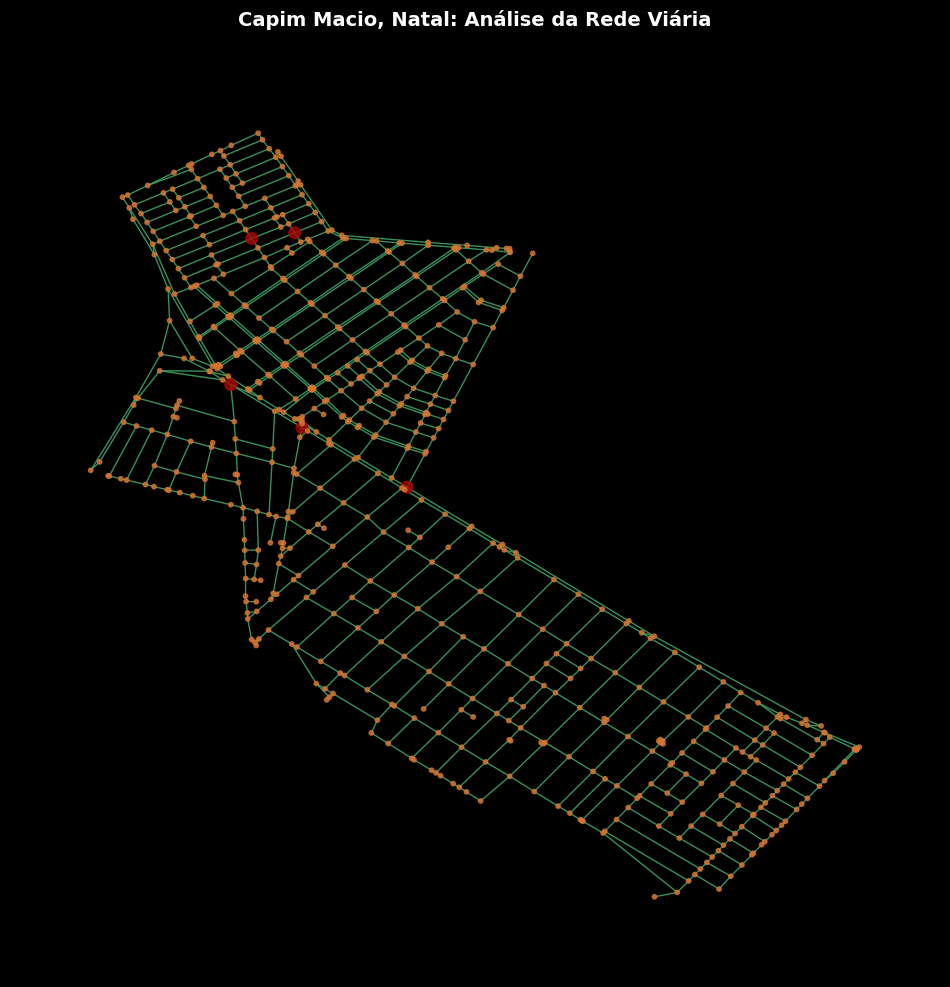

In [50]:
# Extraindo as posições dos nós para o layout geográfico
# pos = {node: (data['x'], data['y']) for node, data in G_undirected.nodes(data=True)}
# Extraindo as posições e forçando a conversão de texto para número (float)
pos = {node: (float(data['x']), float(data['y'])) for node, data in G_undirected.nodes(data=True)}

# Top 5 maiores
top_degree5 = [
    no for no, grau in sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:5]
]

# Definir tamanhos: nós normais = 7, top 5 = 12
tamanhos_nos = [
    70 if no in top_degree5 else 10
    for no in G_undirected.nodes()
]

cores_nos = [
    "#A80606" if no in top_degree5 else "#D57530" 
    for no in G_undirected.nodes()
]

# 2. Configurar a figura
fig, ax = plt.subplots(figsize=(12, 12))
fig.set_facecolor("#000000")  # Cor de fundo suave
ax.set_facecolor("#000000")  # Cor de fundo suave

# 3. Desenhar as arestas (ruas)
nx.draw_networkx_edges(
    G_undirected, 
    pos, 
    ax=ax, 
    edge_color="#47B471",  # Código Hex para Dourado (Gold) #A98200
    width=1, 
    alpha=0.8,             # Leve transparência para dar sofisticação
    arrows=False
)

# 4. Desenhar os nós (pontos/interseções) - Opcional
# Aqui deixamos pequenos para não poluir
nx.draw_networkx_nodes(
    G_undirected, 
    pos, 
    ax=ax, 
    node_size=tamanhos_nos,           # Tamanho pequeno para não esconder as ruas
    alpha=0.8,
    node_color=cores_nos   # Vermelho Puro
)

# 5. Ajustes estéticos finais
ax.set_title("Capim Macio, Natal: Análise da Rede Viária", color='white', fontsize=14, fontweight='semibold', pad=20)
ax.set_axis_off()          # Remove as bordas e números dos eixos

# 6. Salvar em alta definição
plt.savefig("mapa_custom.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

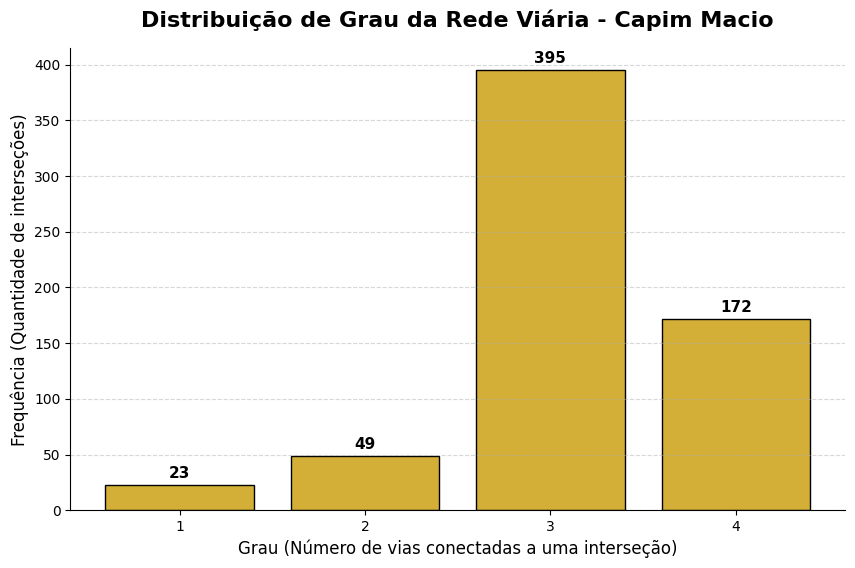

In [22]:
# Plotando a Distribuição de Grau (Aprimorado)

# 1. Extraindo apenas os valores de grau
graus = list(degree_dict.values())

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Configurando as barras (bins) para números inteiros exatos
min_grau = min(graus)
max_grau = max(graus)
bins_inteiros = range(min_grau, max_grau + 2)

# 3. Plotando o histograma (rwidth dá um espaçamento elegante entre as barras)
ax.hist(graus, bins=bins_inteiros, align='left', color='#D4AF37', edgecolor='black', rwidth=0.8)

# 4. Ajustes de título e eixos
ax.set_title("Distribuição de Grau da Rede Viária - Capim Macio", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Grau (Número de vias conectadas a uma interseção)", fontsize=12)
ax.set_ylabel("Frequência (Quantidade de interseções)", fontsize=12)

# 5. Forçando o eixo X a exibir APENAS números inteiros
ax.set_xticks(range(min_grau, max_grau + 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 6. BÔNUS: Adicionando o número exato no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Só coloca número se a barra existir
        ax.annotate(f'{int(altura)}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 3), textcoords='offset points')

# Remove as bordas superior e direita para um visual mais limpo (Data-ink ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [10]:
# Exibição dos resultados e verificação de coincidências
print("TOP 10 HUBS (GRAU)")
for node, degree in top_degree:
    print(f"ID: {node} | Grau: {degree}")

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTOP 10 GARGALOS (BETWEENNESS)")
for node, bc in top_betweenness:
    print(f"ID: {node} | BC: {bc:.4f}")

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n TOP 10 ACESSO RÁPIDO (CLOSENESS)")
for node, cc in top_closeness:
    print(f"ID: {node} | CC: {cc:.4f}")

hubs_ids = {node for node, degree in top_degree}
betweenness_ids = {node for node, bc in top_betweenness}
print(f"\nNós que são simultaneamente Top 10 em Grau e Top 10 em Betweenness: {len(hubs_ids.intersection(betweenness_ids))}")

TOP 10 HUBS (GRAU)
ID: 501733831 | Grau: 4
ID: 501801945 | Grau: 4
ID: 501801948 | Grau: 4
ID: 501834691 | Grau: 4
ID: 501834695 | Grau: 4
ID: 501834699 | Grau: 4
ID: 501834704 | Grau: 4
ID: 501834708 | Grau: 4
ID: 501834715 | Grau: 4
ID: 501834717 | Grau: 4

TOP 10 GARGALOS (BETWEENNESS)
ID: 501733831 | BC: 0.4125
ID: 502407567 | BC: 0.3841
ID: 8632954108 | BC: 0.3099
ID: 1215688818 | BC: 0.3096
ID: 596783041 | BC: 0.3069
ID: 501838342 | BC: 0.2560
ID: 501838267 | BC: 0.2379
ID: 501841251 | BC: 0.2252
ID: 503300664 | BC: 0.2200
ID: 501801948 | BC: 0.2192

 TOP 10 ACESSO RÁPIDO (CLOSENESS)
ID: 501838267 | CC: 0.0816
ID: 501841251 | CC: 0.0809
ID: 501838342 | CC: 0.0804
ID: 501733831 | CC: 0.0803
ID: 501838268 | CC: 0.0796
ID: 2625554557 | CC: 0.0793
ID: 505404810 | CC: 0.0791
ID: 502407567 | CC: 0.0783
ID: 501801946 | CC: 0.0783
ID: 505404811 | CC: 0.0782

Nós que são simultaneamente Top 10 em Grau e Top 10 em Betweenness: 2


In [26]:
metricas = {
    'Grau_ID': [node for node, val in top_degree],
    'Grau_Valor': [val for node, val in top_degree],
    
    'Betweenness_ID': [node for node, val in top_betweenness],
    'Betweenness_Valor': [val for node, val in top_betweenness],
    
    'Closeness_ID': [node for node, val in top_closeness],
    'Closeness_Valor': [val for node, val in top_closeness]
}
df_metricas = pd.DataFrame(metricas)
display(df_metricas)

,Grau_ID,Grau_Valor,Betweenness_ID,Betweenness_Valor,Closeness_ID,Closeness_Valor
0,501733831,4,501733831,0.412496,501838267,0.081554
1,501801945,4,502407567,0.384147,501841251,0.080934
2,501801948,4,8632954108,0.309889,501838342,0.080434
3,501834691,4,1215688818,0.309552,501733831,0.080272
4,501834695,4,596783041,0.306894,501838268,0.079631
5,501834699,4,501838342,0.255988,2625554557,0.079314
6,501834704,4,501838267,0.237935,505404810,0.079097
7,501834708,4,501841251,0.225180,502407567,0.078311
8,501834715,4,503300664,0.219986,501801946,0.078301
9,501834717,4,501801948,0.219194,505404811,0.078177
